# Module 4 — Notebook 3: Business Intelligence & Actionable Insights

**Purpose:** Convert the segmentation outputs from Notebook 2 into business-ready insights, customer targeting lists, dashboards, and strategic recommendations.

**Inputs:**
- `customer_segments_model_outputs.csv`
- `rfm_segment_summary.csv`
- `kmeans_cluster_profiles.csv`
- `hybrid_segment_profiles.csv`
- `model_comparison_report.csv`

**Outputs:**
- `customer_segments_final.csv`
- `segment_profiles.xlsx`
- `targeting_playbook.md`
- `business_insights_summary.json`
- report-ready figures

## 0. Setup

This cell defines paths and helper functions. It uses string paths and `os.path.join` for compatibility with the previous notebooks.

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 80)

# Input/output folders
OUTPUT_DIR = '../Module 4'
FIGURE_DIR = '../Module 4/figures_notebook3'
REPORT_DIR = '../Module 4'

for d in [OUTPUT_DIR, FIGURE_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

# Input paths from Notebook 2
SEGMENTS_PATH = os.path.join(OUTPUT_DIR, 'customer_segments_model_outputs.csv')
RFM_SUMMARY_PATH = os.path.join(OUTPUT_DIR, 'rfm_segment_summary.csv')
KMEANS_PROFILES_PATH = os.path.join(OUTPUT_DIR, 'kmeans_cluster_profiles.csv')
HYBRID_PROFILES_PATH = os.path.join(OUTPUT_DIR, 'hybrid_segment_profiles.csv')
MODEL_COMPARISON_PATH = os.path.join(OUTPUT_DIR, 'model_comparison_report.csv')

# Output paths
FINAL_SEGMENTS_PATH = os.path.join(OUTPUT_DIR, 'customer_segments_final.csv')
SEGMENT_PROFILES_XLSX_PATH = os.path.join(OUTPUT_DIR, 'segment_profiles.xlsx')
TARGETING_PLAYBOOK_PATH = os.path.join(OUTPUT_DIR, 'targeting_playbook.md')
INSIGHTS_SUMMARY_PATH = os.path.join(OUTPUT_DIR, 'business_insights_summary.json')

RANDOM_STATE = 42


def save_current_figure(filename, dpi=160):
    path = os.path.join(FIGURE_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print('Saved:', path)

print('Input directory:', OUTPUT_DIR)
print('Figure directory:', FIGURE_DIR)

Input directory: ../Module 4
Figure directory: ../Module 4/figures_notebook3


## 1. Load segmentation outputs

Loads all outputs generated by Notebook 2.

In [2]:
customer_segments = pd.read_csv(SEGMENTS_PATH)
rfm_summary = pd.read_csv(RFM_SUMMARY_PATH)
kmeans_profiles = pd.read_csv(KMEANS_PROFILES_PATH)
hybrid_profiles = pd.read_csv(HYBRID_PROFILES_PATH)

if os.path.exists(MODEL_COMPARISON_PATH):
    model_comparison = pd.read_csv(MODEL_COMPARISON_PATH)
else:
    model_comparison = pd.DataFrame()

print('Customer segmentation output shape:', customer_segments.shape)
print('RFM summary shape:', rfm_summary.shape)
print('K-Means profiles shape:', kmeans_profiles.shape)
print('Hybrid profiles shape:', hybrid_profiles.shape)
print('Model comparison shape:', model_comparison.shape)

display(customer_segments.head())

Customer segmentation output shape: (10001, 84)
RFM summary shape: (9, 7)
K-Means profiles shape: (5, 12)
Hybrid profiles shape: (15, 11)
Model comparison shape: (4, 6)


,customer_id,profile_transaction_match,archetype,price_tier,time_preference,day_preference,basket_size_bias,preferred_sections,preferred_categories,expected_visits,actual_visits,visit_gap,visit_ratio,under_engaged_flag,last_order_date,first_order_date,frequency,monetary,recency,customer_tenure_days,monetary_per_order,R_score,F_score,M_score,rfm_score,rfm_code,total_orders,avg_order_value,median_order_value,max_order_value,avg_basket_size,median_basket_size,avg_unique_items_per_order,avg_categories_per_order,avg_item_price,avg_discount_pct,discount_order_rate,total_discount_amount_est,payment_share_card,payment_share_cash,payment_share_mobile,preferred_payment_method,avg_order_hour,std_order_hour,weekend_order_rate,dow_share_friday,dow_share_monday,dow_share_saturday,dow_share_sunday,dow_share_thursday,dow_share_tuesday,dow_share_wednesday,meal_share_dinner,meal_share_late_night,meal_share_lunch,meal_share_morning,dominant_meal_period,dominant_day_of_week,category_share_alcohol,category_share_appetizer,category_share_bakery,category_share_beverage,category_share_dessert,category_share_food,category_share_main,category_share_side,section_share_american,section_share_cafe,section_share_healthy_vegan,section_share_italian,section_share_japanese,section_share_mexican,section_share_steakhouse,unique_items_bought,unique_categories_bought,unique_sections_bought,dominant_category,dominant_section,rfm_segment,gmm_cluster,kmeans_cluster,kmeans_segment_name,rfm_value_tier,hybrid_segment
0,5485,both,infrequent,premium,dinner,weekday,small,Steakhouse,"Alcohol,Side",2.0,2.0,0.0,1.000000,0,2025-11-09 19:30:00,2025-05-13 21:00:00,2.0,136.00,53.0,179.0,68.000000,5,2,4,11,524,2.0,68.000000,68.000,82.0,2.5,2.5,2.5,2.00,27.166667,0.0,0.00,0.0000,0.500,0.5000,0.0000,card,20.000,1.414214,0.5000,0.0000,0.0000,0.00,0.5000,0.0000,0.500,0.000,1.00,0.0,0.0,0.00,dinner,Sunday,0.110294,0.117647,0.000000,0.000000,0.000000,0.000000,0.772059,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,5.0,3.0,1.0,Main,Steakhouse,New / Promising,1,0,High-Value Inactive Large-Basket,Mid-Value,Mid-Value | High-Value Inactive Large-Basket
1,7761,both,infrequent,budget,dinner,weekday,large,"Steakhouse,Mexican","Alcohol,Main",4.0,4.0,0.0,1.000000,0,2025-02-11 19:30:00,2024-04-14 19:00:00,4.0,189.00,324.0,303.0,47.250000,3,3,4,10,334,4.0,47.250000,38.000,83.0,4.0,4.0,4.0,2.25,11.868750,0.0,0.00,0.0000,0.500,0.2500,0.2500,card,19.250,0.500000,0.2500,0.5000,0.0000,0.00,0.2500,0.0000,0.250,0.000,1.00,0.0,0.0,0.00,dinner,Friday,0.169312,0.000000,0.000000,0.000000,0.000000,0.000000,0.682540,0.148148,0.000000,0.000000,0.0,0.000000,0.000000,0.560847,0.439153,12.0,3.0,2.0,Main,Mexican,Potential Loyalists,1,0,High-Value Inactive Large-Basket,Mid-Value,Mid-Value | High-Value Inactive Large-Basket
2,1774,both,occasional,budget,lunch,weekday,large,"Healthy_Vegan,American","Bakery,Beverage",5.0,5.0,0.0,1.000000,0,2024-08-07 12:30:00,2023-02-01 12:30:00,5.0,128.30,512.0,553.0,25.660000,2,3,3,8,233,5.0,25.660000,25.000,32.3,4.0,4.0,4.0,2.60,6.650000,1.0,0.20,1.7000,0.800,0.0000,0.2000,card,11.800,0.447214,0.2000,0.0000,0.0000,0.20,0.0000,0.0000,0.200,0.600,0.00,0.0,1.0,0.00,lunch,Wednesday,0.000000,0.000000,0.000000,0.139361,0.038971,0.000000,0.755417,0.066251,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,12.0,4.0,1.0,Main,American,At Risk,2,3,Mid-Value Occasional Discount-Sensitive,Mid-Value,Mid-Value | Mid-Value Occasional Discount-Sensitive
3,3417,both,occasional,premium,dinner,any,medium,Japanese,"Alcohol,Dessert",6.0,6.0,0.0,1.000000,0,2025-10-17 20:00:00,2024-02-24 09:00:00,5.0,148.75,76.0,601.0,29.750000,4,3,4,11,434,5.0,29.750000,25.500,50.0,3.4,4.0,3.4,2.20,10.707500,0.0,0.00,0.0000,0.200,0.6000,0.2000,cash,15.000,6.000000,0.6000,0.4000,0.0000,0.40,0.2000,0.0000,0.000,0.000,0.60,0.0,0.0,0.40,dinner,Friday,0.100840,0.060504,0.040336,0.126050,0.000000,0.134454,0.537815,0.000000,0.137815,0.300840,0.0,0.000000,0.225210,0.000000,0.336134,17.0,6.0,4.0,Main,Ste

## 2. Final validation checks

Verifies that the final segmentation table contains all required segment labels.

In [3]:
required_cols = [
    'customer_id', 'rfm_segment', 'rfm_value_tier',
    'kmeans_cluster', 'kmeans_segment_name', 'hybrid_segment'
]

missing_required = [c for c in required_cols if c not in customer_segments.columns]
print('Missing required columns:', missing_required)
print('Duplicate customer IDs:', customer_segments['customer_id'].duplicated().sum())
print('Unique customers:', customer_segments['customer_id'].nunique())
print('RFM segments:', customer_segments['rfm_segment'].nunique())
print('K-Means clusters:', customer_segments['kmeans_cluster'].nunique())
print('Hybrid segments:', customer_segments['hybrid_segment'].nunique())

segment_missing = customer_segments[required_cols].isna().sum()
display(segment_missing.to_frame('missing_values'))

Missing required columns: []
Duplicate customer IDs: 0
Unique customers: 10001
RFM segments: 9
K-Means clusters: 5
Hybrid segments: 15


,missing_values
customer_id,0
rfm_segment,0
rfm_value_tier,0
kmeans_cluster,0
kmeans_segment_name,0
hybrid_segment,0


## 3. Executive KPI summary

Creates high-level business KPIs for the segmentation module.

In [4]:
total_customers = customer_segments['customer_id'].nunique()
total_revenue = customer_segments['monetary'].sum() if 'monetary' in customer_segments.columns else customer_segments['total_revenue'].sum()
avg_monetary = customer_segments['monetary'].mean() if 'monetary' in customer_segments.columns else np.nan
avg_frequency = customer_segments['frequency'].mean() if 'frequency' in customer_segments.columns else np.nan
avg_recency = customer_segments['recency'].mean() if 'recency' in customer_segments.columns else np.nan

high_value_count = (customer_segments['rfm_value_tier'] == 'High-Value').sum()
low_value_count = (customer_segments['rfm_value_tier'] == 'Low-Value').sum()

summary_kpis = pd.DataFrame({
    'metric': [
        'Total customers', 'Total revenue', 'Average monetary value',
        'Average frequency', 'Average recency', 'High-value customers',
        'Low-value customers', 'RFM segments', 'K-Means clusters', 'Hybrid segments'
    ],
    'value': [
        total_customers, round(total_revenue, 2), round(avg_monetary, 2),
        round(avg_frequency, 2), round(avg_recency, 2), high_value_count,
        low_value_count, customer_segments['rfm_segment'].nunique(),
        customer_segments['kmeans_cluster'].nunique(), customer_segments['hybrid_segment'].nunique()
    ]
})

display(summary_kpis)

,metric,value
0,Total customers,10001.00
1,Total revenue,1601881.79
2,Average monetary value,160.17
3,Average frequency,6.20
4,Average recency,384.12
5,High-value customers,3230.00
6,Low-value customers,3991.00
7,RFM segments,9.00
8,K-Means clusters,5.00
9,Hybrid segments,15.00


## 4. RFM business overview

RFM gives the customer lifecycle/value view: who is active, loyal, at risk, lost, or high value.

In [5]:
rfm_overview = (
    customer_segments
    .groupby('rfm_segment', as_index=False)
    .agg(
        customers=('customer_id', 'count'),
        total_revenue=('monetary', 'sum'),
        avg_monetary=('monetary', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_recency=('recency', 'mean')
    )
    .sort_values('total_revenue', ascending=False)
)

rfm_overview['customer_pct'] = rfm_overview['customers'] / rfm_overview['customers'].sum() * 100
rfm_overview['revenue_pct'] = rfm_overview['total_revenue'] / rfm_overview['total_revenue'].sum() * 100

display(rfm_overview)

,rfm_segment,customers,total_revenue,avg_monetary,avg_frequency,avg_recency,customer_pct,revenue_pct
2,Champions,2728,991652.09,363.508831,13.577713,60.109604,27.277272,61.905447
4,Loyal Customers,1054,197698.49,187.569725,8.444023,213.721063,10.538946,12.341640
8,Potential Loyalists,992,118606.38,119.562883,3.977823,228.961694,9.919008,7.404191
0,At Risk,804,101838.90,126.665299,4.737562,541.776119,8.039196,6.357454
3,Lost / Hibernating,2625,79279.65,30.201771,1.384000,788.301714,26.247375,4.949157
7,Others,902,73477.41,81.460543,3.150776,560.392461,9.019098,4.586943
5,Need Attention,520,19045.13,36.625250,1.842308,322.780769,5.199480,1.188922
6,New / Promising,368,18795.83,51.075625,2.187500,111.470109,3.679632,1.173359
1,Cannot Lose Them,8,1487.91,185.988750,6.625000,745.750000,0.079992,0.092885


### 4.1 RFM segment size distribution

Saved: ../Module 4/figures_notebook3\fig_01_rfm_customer_count.png


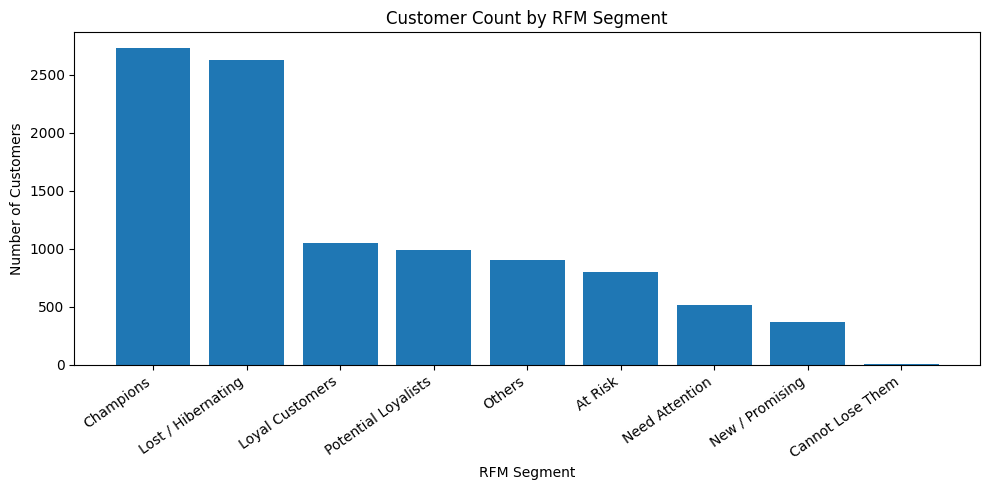

In [6]:
rfm_counts = rfm_overview.sort_values('customers', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(rfm_counts['rfm_segment'], rfm_counts['customers'])
plt.title('Customer Count by RFM Segment')
plt.xlabel('RFM Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=35, ha='right')
save_current_figure('fig_01_rfm_customer_count.png')
plt.show()

### 4.2 RFM revenue contribution

Saved: ../Module 4/figures_notebook3\fig_02_rfm_revenue_contribution.png


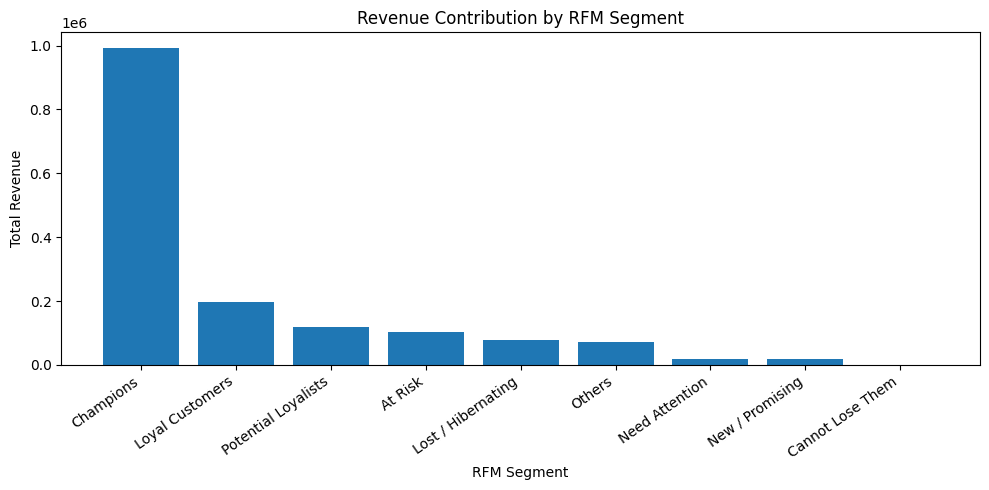

In [7]:
rfm_revenue = rfm_overview.sort_values('total_revenue', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(rfm_revenue['rfm_segment'], rfm_revenue['total_revenue'])
plt.title('Revenue Contribution by RFM Segment')
plt.xlabel('RFM Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=35, ha='right')
save_current_figure('fig_02_rfm_revenue_contribution.png')
plt.show()

### 4.3 RFM revenue share percentage

Saved: ../Module 4/figures_notebook3\fig_03_rfm_revenue_share_pie.png


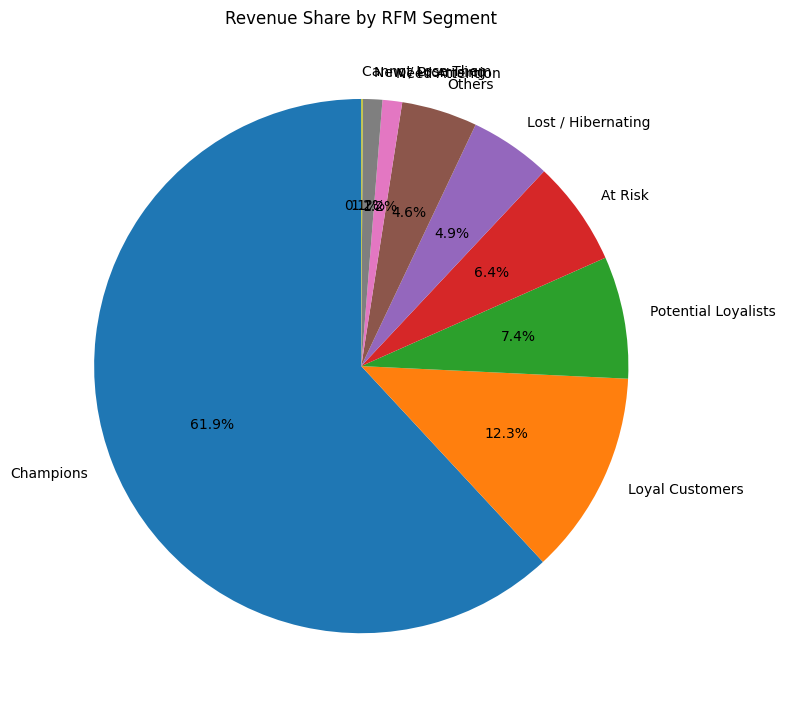

In [8]:
plt.figure(figsize=(8, 8))
plt.pie(
    rfm_revenue['revenue_pct'],
    labels=rfm_revenue['rfm_segment'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Revenue Share by RFM Segment')
save_current_figure('fig_03_rfm_revenue_share_pie.png')
plt.show()

## 5. K-Means behavioral segment overview

K-Means gives the behavioral layer: it explains how customers differ by basket, activity, value, discount usage, timing, and preferences.

In [9]:
kmeans_overview = (
    customer_segments
    .groupby(['kmeans_cluster', 'kmeans_segment_name'], as_index=False)
    .agg(
        customers=('customer_id', 'count'),
        total_revenue=('monetary', 'sum'),
        avg_monetary=('monetary', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_recency=('recency', 'mean'),
        avg_order_value=('avg_order_value', 'mean'),
        avg_basket_size=('avg_basket_size', 'mean'),
        avg_discount_pct=('avg_discount_pct', 'mean'),
        weekend_order_rate=('weekend_order_rate', 'mean'),
        avg_visit_gap=('visit_gap', 'mean')
    )
    .sort_values('total_revenue', ascending=False)
)

kmeans_overview['customer_pct'] = kmeans_overview['customers'] / kmeans_overview['customers'].sum() * 100
kmeans_overview['revenue_pct'] = kmeans_overview['total_revenue'] / kmeans_overview['total_revenue'].sum() * 100

display(kmeans_overview)

,kmeans_cluster,kmeans_segment_name,customers,total_revenue,avg_monetary,avg_frequency,avg_recency,avg_order_value,avg_basket_size,avg_discount_pct,weekend_order_rate,avg_visit_gap,customer_pct,revenue_pct
1,1,High-Value Frequent Discount-Sensitive,1926,799481.66,415.099512,14.924714,77.794393,27.767473,2.858763,1.752363,0.338522,2.362409,19.258074,49.908905
0,0,High-Value Inactive Large-Basket,2045,313976.06,153.533526,3.732518,492.617115,41.264632,3.432817,1.520418,0.355438,0.047433,20.447955,19.600451
4,4,Low-Value Inactive Standard,2578,184660.57,71.629391,3.349108,523.879752,20.503406,2.236137,1.617120,0.341431,0.048487,25.777422,11.527728
3,3,Mid-Value Occasional Discount-Sensitive,1741,167268.01,96.075824,4.452613,408.651350,21.815259,2.830730,1.659479,0.290307,0.364159,17.408259,10.441970
2,2,Low-Value Frequent Weekend-Oriented,1711,136495.49,79.775272,5.389831,363.705435,14.387011,2.815456,1.542152,0.341712,1.071303,17.108289,8.520946


### 5.1 K-Means customer count by segment

Saved: ../Module 4/figures_notebook3\fig_04_kmeans_customer_count.png


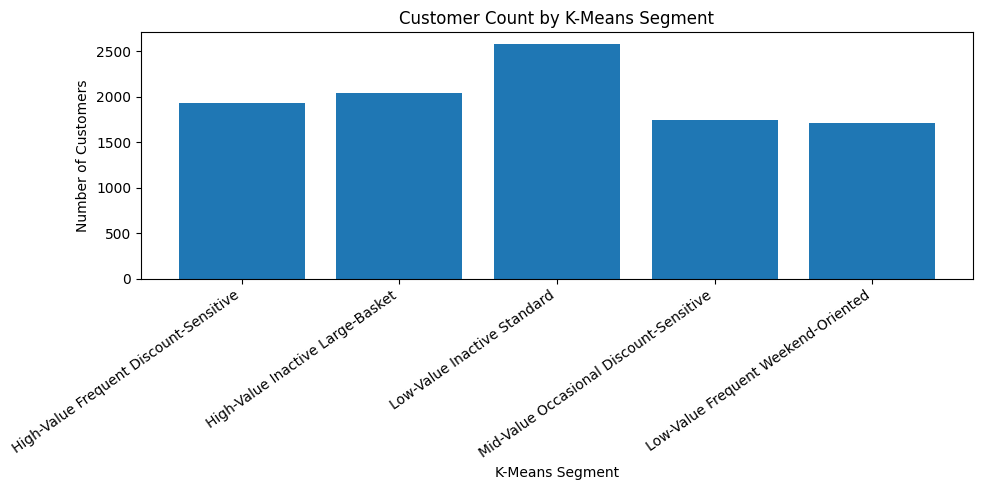

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(kmeans_overview['kmeans_segment_name'], kmeans_overview['customers'])
plt.title('Customer Count by K-Means Segment')
plt.xlabel('K-Means Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=35, ha='right')
save_current_figure('fig_04_kmeans_customer_count.png')
plt.show()

### 5.2 K-Means revenue by segment

Saved: ../Module 4/figures_notebook3\fig_05_kmeans_revenue.png


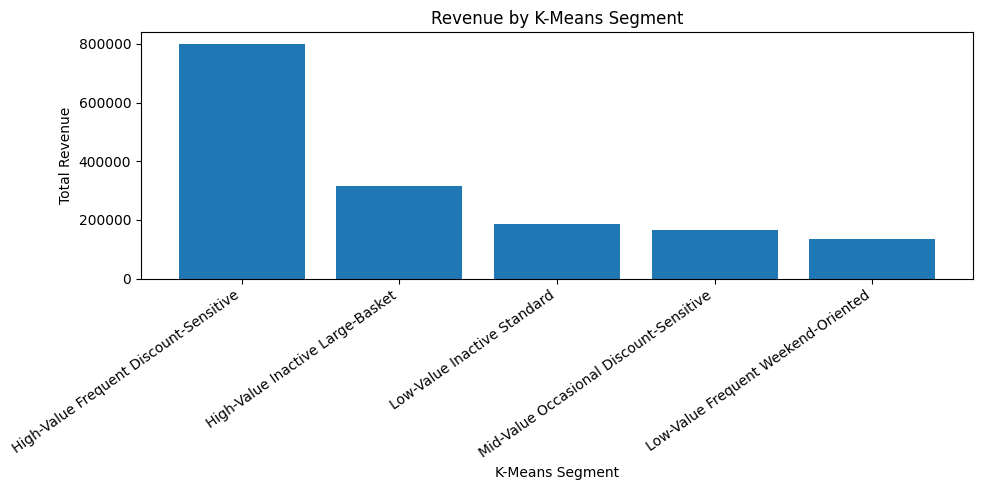

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(kmeans_overview['kmeans_segment_name'], kmeans_overview['total_revenue'])
plt.title('Revenue by K-Means Segment')
plt.xlabel('K-Means Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=35, ha='right')
save_current_figure('fig_05_kmeans_revenue.png')
plt.show()

### 5.3 K-Means segment profile heatmap

Saved: ../Module 4/figures_notebook3\fig_06_kmeans_profile_heatmap.png


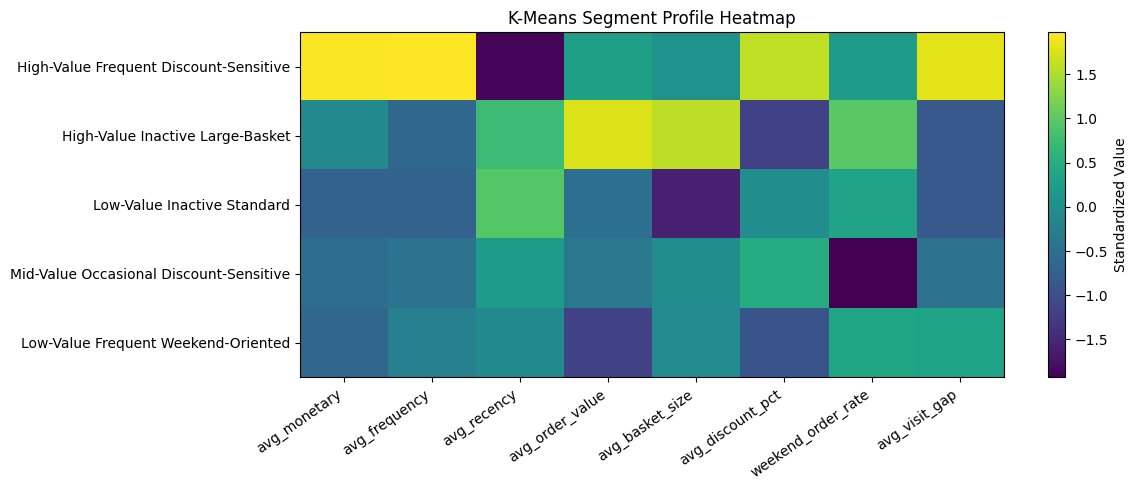

In [12]:
heatmap_cols = [
    "avg_monetary", "avg_frequency", "avg_recency", "avg_order_value",
    "avg_basket_size", "avg_discount_pct", "weekend_order_rate", "avg_visit_gap"
]

heatmap_data = kmeans_overview.set_index("kmeans_segment_name")[heatmap_cols]
heatmap_scaled = (heatmap_data - heatmap_data.mean()) / heatmap_data.std(ddof=0)

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(heatmap_scaled.values, aspect="auto")
fig.colorbar(im, ax=ax, label="Standardized Value")

ax.set_xticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, rotation=35, ha="right")

ax.set_yticks(range(len(heatmap_scaled.index)))
ax.set_yticklabels(heatmap_scaled.index)

ax.set_title("K-Means Segment Profile Heatmap")

plt.tight_layout()

# Safe save
fig_path = os.path.join(FIGURE_DIR, "fig_06_kmeans_profile_heatmap.png")
fig.savefig(fig_path, dpi=100, bbox_inches="tight")
print("Saved:", fig_path)

plt.show()
plt.close(fig)

## 6. Hybrid segment overview

Hybrid segmentation combines RFM value/lifecycle with K-Means behavioral identity. This is the final business-ready segmentation layer.

In [13]:
hybrid_overview = (
    customer_segments
    .groupby('hybrid_segment', as_index=False)
    .agg(
        customers=('customer_id', 'count'),
        total_revenue=('monetary', 'sum'),
        avg_monetary=('monetary', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_recency=('recency', 'mean'),
        avg_order_value=('avg_order_value', 'mean'),
        avg_basket_size=('avg_basket_size', 'mean'),
        avg_discount_pct=('avg_discount_pct', 'mean'),
        avg_visit_gap=('visit_gap', 'mean')
    )
    .sort_values('total_revenue', ascending=False)
)

hybrid_overview['customer_pct'] = hybrid_overview['customers'] / hybrid_overview['customers'].sum() * 100
hybrid_overview['revenue_pct'] = hybrid_overview['total_revenue'] / hybrid_overview['total_revenue'].sum() * 100
hybrid_overview['revenue_per_customer'] = hybrid_overview['total_revenue'] / hybrid_overview['customers']

display(hybrid_overview)

,hybrid_segment,customers,total_revenue,avg_monetary,avg_frequency,avg_recency,avg_order_value,avg_basket_size,avg_discount_pct,avg_visit_gap,customer_pct,revenue_pct,revenue_per_customer
0,High-Value | High-Value Frequent Discount-Sensitive,1834,783385.19,427.145687,15.310251,68.500000,27.953483,2.858489,1.654367,2.378408,18.338166,48.904057,427.145687
11,Mid-Value | High-Value Inactive Large-Basket,828,130844.26,158.024469,4.131643,383.049517,39.562305,3.297430,1.340870,0.033816,8.279172,8.168160,158.024469
1,High-Value | High-Value Inactive Large-Basket,345,126572.71,366.877420,8.200000,136.785507,41.483911,3.336006,1.323231,0.182609,3.449655,7.901501,366.877420
13,Mid-Value | Low-Value Inactive Standard,784,84132.41,107.311747,4.825255,307.751276,22.575996,2.386502,1.401652,0.096939,7.839216,5.252099,107.311747
2,High-Value | Low-Value Frequent Weekend-Oriented,446,80521.21,180.540830,11.793722,49.291480,15.508079,2.840886,1.457863,3.322870,4.459554,5.026664,180.540830
4,High-Value | Mid-Value Occasional Discount-Sensitive,362,77694.33,214.625221,9.754144,78.024862,22.401746,2.825167,1.591082,0.972376,3.619638,4.850191,214.625221
14,Mid-Value | Mid-Value Occasional Discount-Sensitive,596,60857.09,102.109211,4.738255,270.697987,22.140998,2.857534,1.594964,0.387584,5.959404,3.799100,102.109211
6,Low-Value | High-Value Inactive Large-Basket,872,56559.09,64.861342,1.586009,737.438073,42.794305,3.599675,1.768922,0.006881,8.719128,3.530790,64.861342
8,Low-Value | Low-Value Inactive Standard,1551,53473.44,34.476750,1.738233,696.038040,19.202460,2.146346,1.797711,0.021921,15.508449,3.338164,34.476750
3,High-Value | Low-Value Inactive Standard,243,47054.72,193.640823,8.868313,122.345679,22.120093,2.324115,1.159628,0.061728,2.429757,2.937465,193.640823


### 6.1 Top hybrid segments by customer count

Saved: ../Module 4/figures_notebook3\fig_07_hybrid_customer_count.png


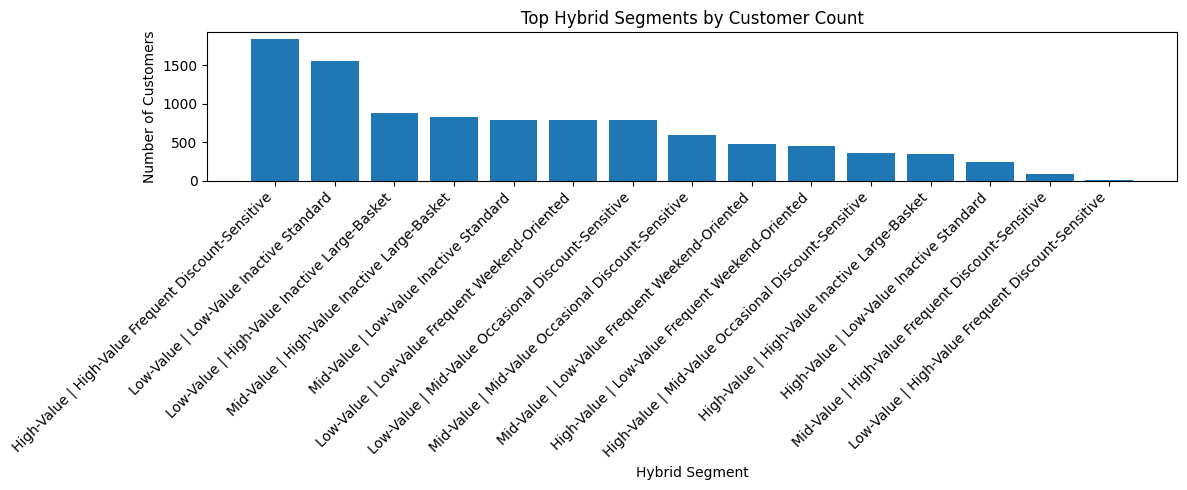

In [14]:
top_hybrid_count = hybrid_overview.sort_values('customers', ascending=False).head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_hybrid_count['hybrid_segment'], top_hybrid_count['customers'])
plt.title('Top Hybrid Segments by Customer Count')
plt.xlabel('Hybrid Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
save_current_figure('fig_07_hybrid_customer_count.png')
plt.show()

### 6.2 Top hybrid segments by revenue

Saved: ../Module 4/figures_notebook3\fig_08_hybrid_revenue.png


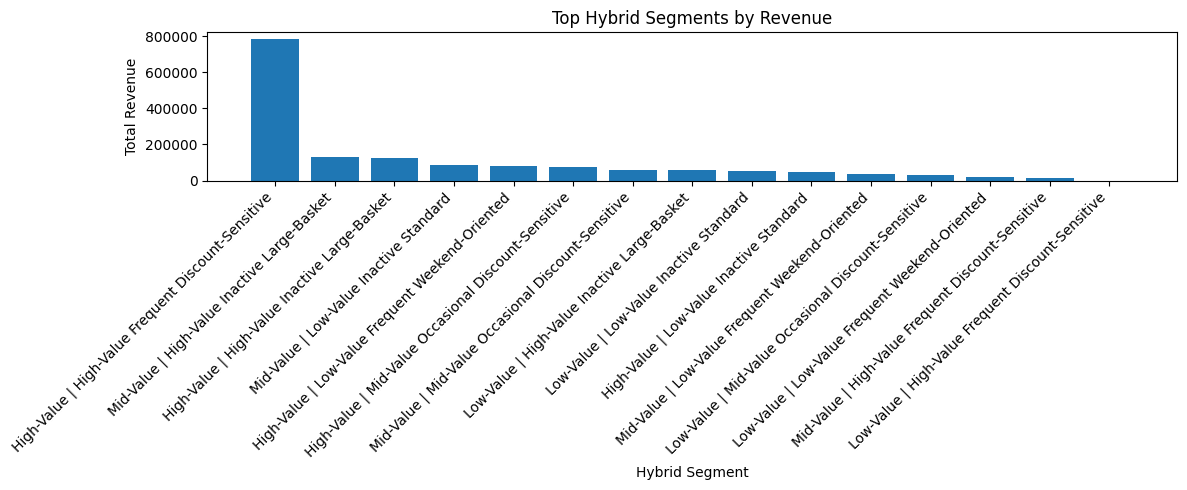

In [15]:
top_hybrid_revenue = hybrid_overview.sort_values('total_revenue', ascending=False).head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_hybrid_revenue['hybrid_segment'], top_hybrid_revenue['total_revenue'])
plt.title('Top Hybrid Segments by Revenue')
plt.xlabel('Hybrid Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
save_current_figure('fig_08_hybrid_revenue.png')
plt.show()

### 6.3 Hybrid revenue Pareto curve

Shows how concentrated revenue is across hybrid segments.

Saved: ../Module 4/figures_notebook3\fig_09_hybrid_revenue_pareto.png


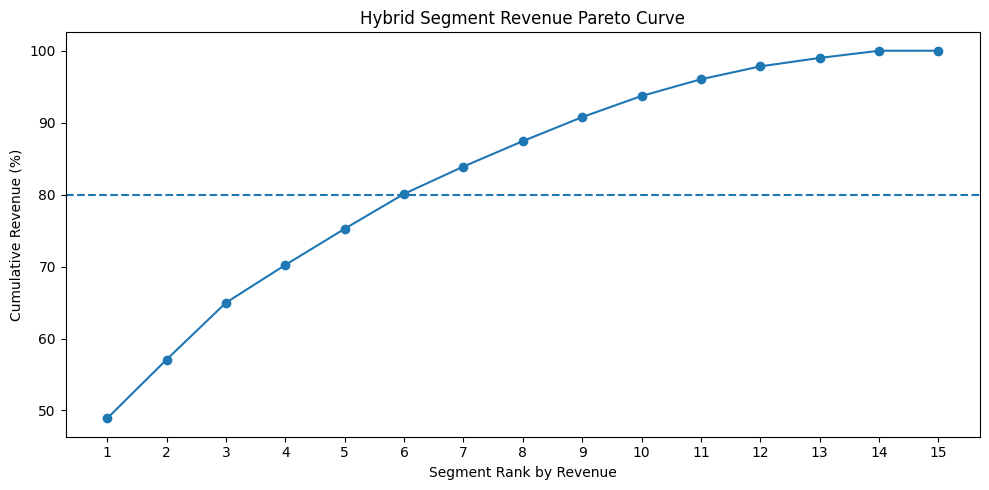

,segment_rank,hybrid_segment,total_revenue,revenue_pct,cum_revenue_pct
0,1,High-Value | High-Value Frequent Discount-Sensitive,783385.19,48.904057,48.904057
11,2,Mid-Value | High-Value Inactive Large-Basket,130844.26,8.168160,57.072217
1,3,High-Value | High-Value Inactive Large-Basket,126572.71,7.901501,64.973718
13,4,Mid-Value | Low-Value Inactive Standard,84132.41,5.252099,70.225817
2,5,High-Value | Low-Value Frequent Weekend-Oriented,80521.21,5.026664,75.252480
4,6,High-Value | Mid-Value Occasional Discount-Sensitive,77694.33,4.850191,80.102672
14,7,Mid-Value | Mid-Value Occasional Discount-Sensitive,60857.09,3.799100,83.901772
6,8,Low-Value | High-Value Inactive Large-Basket,56559.09,3.530790,87.432562
8,9,Low-Value | Low-Value Inactive Standard,53473.44,3.338164,90.770726
3,10,High-Value | Low-Value Inactive Standard,47054.72,2.937465,93.708191


In [16]:
pareto = hybrid_overview.sort_values('total_revenue', ascending=False).copy()
pareto['cum_revenue_pct'] = pareto['total_revenue'].cumsum() / pareto['total_revenue'].sum() * 100
pareto['segment_rank'] = np.arange(1, len(pareto) + 1)

plt.figure(figsize=(10, 5))
plt.plot(pareto['segment_rank'], pareto['cum_revenue_pct'], marker='o')
plt.axhline(80, linestyle='--')
plt.title('Hybrid Segment Revenue Pareto Curve')
plt.xlabel('Segment Rank by Revenue')
plt.ylabel('Cumulative Revenue (%)')
plt.xticks(pareto['segment_rank'])
save_current_figure('fig_09_hybrid_revenue_pareto.png')
plt.show()

display(pareto[['segment_rank', 'hybrid_segment', 'total_revenue', 'revenue_pct', 'cum_revenue_pct']])

### 6.4 Hybrid segment bubble chart

Compares segment size, value per customer, and total revenue.

Saved: ../Module 4/figures_notebook3\fig_10_hybrid_bubble_value_size.png


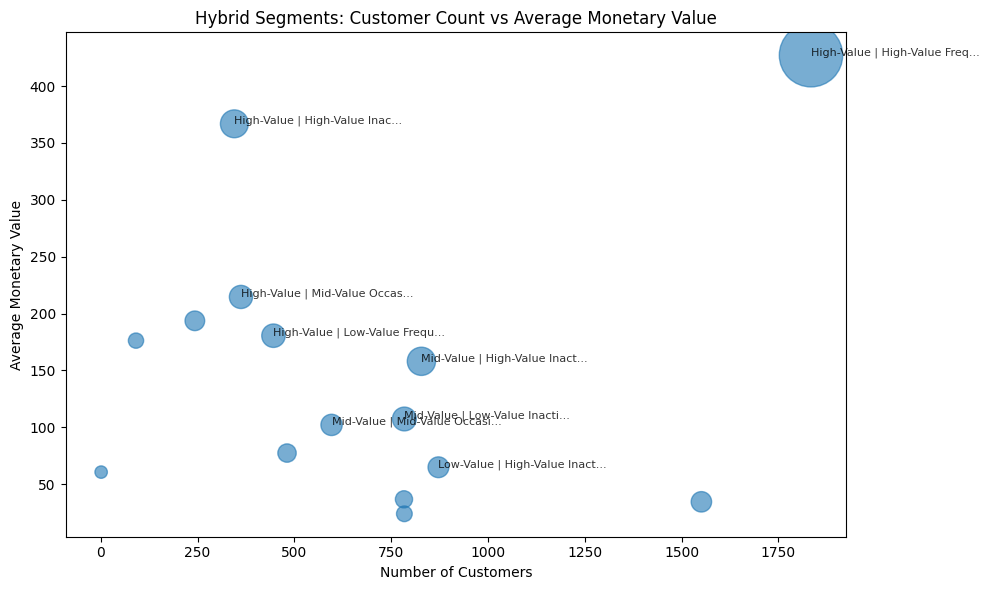

In [17]:
bubble = hybrid_overview.copy()
size_scale = bubble['total_revenue'] / bubble['total_revenue'].max() * 2000 + 80

plt.figure(figsize=(10, 6))
plt.scatter(
    bubble['customers'],
    bubble['avg_monetary'],
    s=size_scale,
    alpha=0.6
)
plt.title('Hybrid Segments: Customer Count vs Average Monetary Value')
plt.xlabel('Number of Customers')
plt.ylabel('Average Monetary Value')

for _, row in bubble.head(8).iterrows():
    label = row['hybrid_segment'][:28] + '...' if len(row['hybrid_segment']) > 28 else row['hybrid_segment']
    plt.annotate(label, (row['customers'], row['avg_monetary']), fontsize=8, alpha=0.8)

save_current_figure('fig_10_hybrid_bubble_value_size.png')
plt.show()

## 7. Strategic customer targeting lists

Creates operational customer lists for marketing and CRM activation.

In [18]:
# Thresholds used for targeting lists
monetary_q75 = customer_segments['monetary'].quantile(0.75)
frequency_q75 = customer_segments['frequency'].quantile(0.75)
recency_q75 = customer_segments['recency'].quantile(0.75)
discount_q75 = customer_segments['avg_discount_pct'].quantile(0.75)
visit_gap_q75 = customer_segments['visit_gap'].quantile(0.75)
basket_q75 = customer_segments['avg_basket_size'].quantile(0.75)
weekend_q75 = customer_segments['weekend_order_rate'].quantile(0.75)

vip_customers = customer_segments[
    (customer_segments['rfm_value_tier'] == 'High-Value') |
    ((customer_segments['monetary'] >= monetary_q75) & (customer_segments['frequency'] >= frequency_q75))
].copy()

churn_risk_customers = customer_segments[
    (customer_segments['rfm_segment'].isin(['At Risk', 'Lost / Hibernating', 'Cannot Lose Them'])) |
    ((customer_segments['recency'] >= recency_q75) & (customer_segments['visit_gap'] >= visit_gap_q75))
].copy()

winback_customers = customer_segments[
    (customer_segments['recency'] >= recency_q75) &
    (customer_segments['monetary'] >= customer_segments['monetary'].median())
].copy()

discount_sensitive_customers = customer_segments[
    (customer_segments['avg_discount_pct'] >= discount_q75) |
    (customer_segments['kmeans_segment_name'].str.contains('Discount', na=False))
].copy()

large_basket_customers = customer_segments[
    customer_segments['avg_basket_size'] >= basket_q75
].copy()

weekend_customers = customer_segments[
    customer_segments['weekend_order_rate'] >= weekend_q75
].copy()

targeting_summary = pd.DataFrame({
    'target_group': [
        'VIP / High-value customers', 'Churn-risk customers', 'Win-back candidates',
        'Discount-sensitive customers', 'Large-basket customers', 'Weekend-oriented customers'
    ],
    'customers': [
        len(vip_customers), len(churn_risk_customers), len(winback_customers),
        len(discount_sensitive_customers), len(large_basket_customers), len(weekend_customers)
    ],
    'total_revenue': [
        vip_customers['monetary'].sum(), churn_risk_customers['monetary'].sum(), winback_customers['monetary'].sum(),
        discount_sensitive_customers['monetary'].sum(), large_basket_customers['monetary'].sum(), weekend_customers['monetary'].sum()
    ]
})

targeting_summary['avg_revenue_per_customer'] = targeting_summary['total_revenue'] / targeting_summary['customers']

display(targeting_summary)

,target_group,customers,total_revenue,avg_revenue_per_customer
0,VIP / High-value customers,3296,1132686.08,343.654757
1,Churn-risk customers,3868,223792.18,57.857337
2,Win-back candidates,258,34358.96,133.174264
3,Discount-sensitive customers,5083,1124167.59,221.162225
4,Large-basket customers,2502,468145.63,187.108565
5,Weekend-oriented customers,3231,418414.29,129.499935


### 7.1 Targeting group sizes

Saved: ../Module 4/figures_notebook3\fig_11_targeting_group_sizes.png


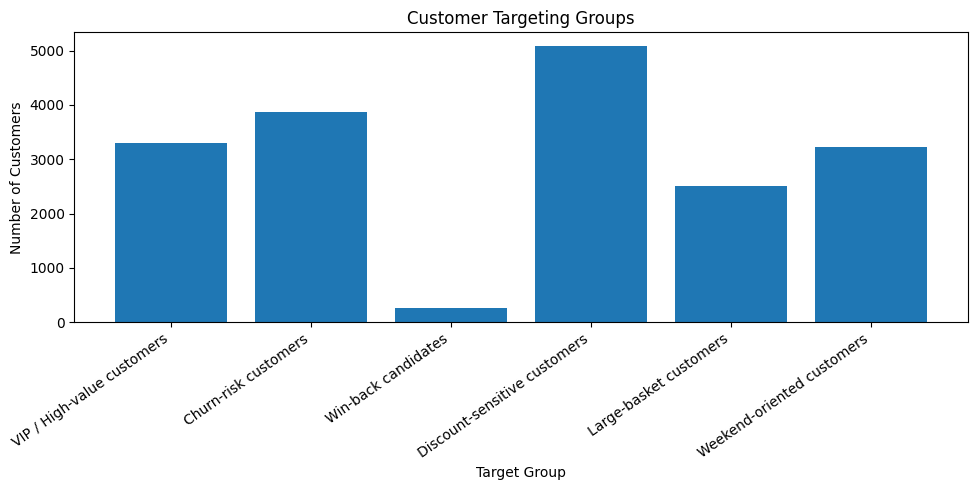

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(targeting_summary['target_group'], targeting_summary['customers'])
plt.title('Customer Targeting Groups')
plt.xlabel('Target Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=35, ha='right')
save_current_figure('fig_11_targeting_group_sizes.png')
plt.show()

### 7.2 Targeting group revenue

Saved: ../Module 4/figures_notebook3\fig_12_targeting_group_revenue.png


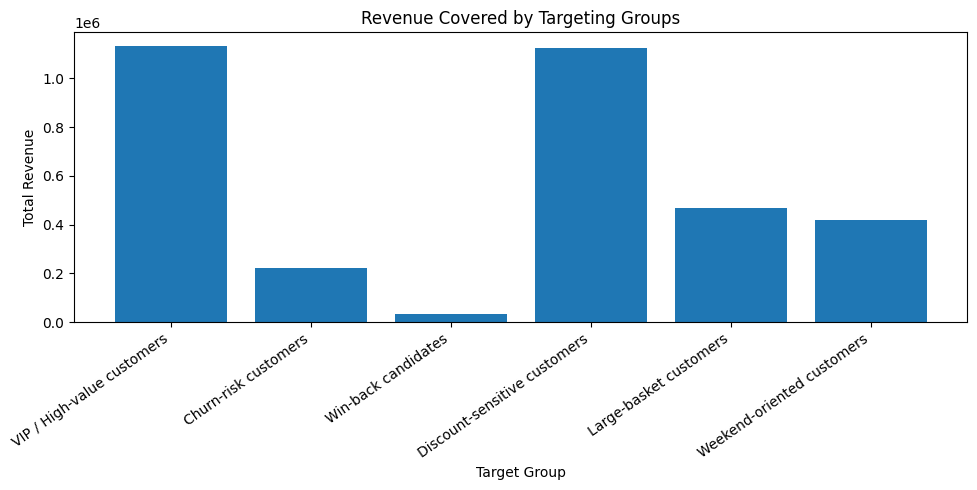

In [20]:
plt.figure(figsize=(10, 5))
plt.bar(targeting_summary['target_group'], targeting_summary['total_revenue'])
plt.title('Revenue Covered by Targeting Groups')
plt.xlabel('Target Group')
plt.ylabel('Total Revenue')
plt.xticks(rotation=35, ha='right')
save_current_figure('fig_12_targeting_group_revenue.png')
plt.show()

## 8. Recommended business actions by hybrid segment

Maps each segment to a practical action: VIP retention, win-back, reactivation, discount campaigns, or premium personalization.

In [21]:
def recommend_action(row):
    segment = str(row['hybrid_segment'])
    avg_recency = row.get('avg_recency', np.nan)
    avg_frequency = row.get('avg_frequency', np.nan)
    avg_monetary = row.get('avg_monetary', np.nan)
    avg_discount = row.get('avg_discount_pct', np.nan)
    avg_visit_gap = row.get('avg_visit_gap', np.nan)

    if segment.startswith('High-Value') and ('Frequent' in segment or avg_frequency >= hybrid_overview['avg_frequency'].quantile(0.70)):
        return 'VIP loyalty program and premium personalization'
    if 'High-Value Inactive' in segment or (avg_recency >= hybrid_overview['avg_recency'].quantile(0.70) and avg_monetary >= hybrid_overview['avg_monetary'].median()):
        return 'Win-back campaign for valuable customers'
    if 'Discount' in segment or avg_discount >= hybrid_overview['avg_discount_pct'].quantile(0.70):
        return 'Targeted promotions and coupon campaigns'
    if avg_visit_gap >= hybrid_overview['avg_visit_gap'].quantile(0.70) or 'Inactive' in segment:
        return 'Reactivation campaign based on visit gap'
    return 'Standard nurturing and personalized recommendations'

hybrid_overview['recommended_action'] = hybrid_overview.apply(recommend_action, axis=1)

action_summary = (
    hybrid_overview
    .groupby('recommended_action', as_index=False)
    .agg(
        segments=('hybrid_segment', 'count'),
        customers=('customers', 'sum'),
        total_revenue=('total_revenue', 'sum')
    )
    .sort_values('total_revenue', ascending=False)
)

display(hybrid_overview[['hybrid_segment', 'customers', 'total_revenue', 'avg_recency', 'avg_frequency', 'avg_basket_size', 'avg_discount_pct', 'avg_visit_gap', 'recommended_action']])
display(action_summary)

,hybrid_segment,customers,total_revenue,avg_recency,avg_frequency,avg_basket_size,avg_discount_pct,avg_visit_gap,recommended_action
0,High-Value | High-Value Frequent Discount-Sensitive,1834,783385.19,68.500000,15.310251,2.858489,1.654367,2.378408,VIP loyalty program and premium personalization
11,Mid-Value | High-Value Inactive Large-Basket,828,130844.26,383.049517,4.131643,3.297430,1.340870,0.033816,Win-back campaign for valuable customers
1,High-Value | High-Value Inactive Large-Basket,345,126572.71,136.785507,8.200000,3.336006,1.323231,0.182609,VIP loyalty program and premium personalization
13,Mid-Value | Low-Value Inactive Standard,784,84132.41,307.751276,4.825255,2.386502,1.401652,0.096939,Reactivation campaign based on visit gap
2,High-Value | Low-Value Frequent Weekend-Oriented,446,80521.21,49.291480,11.793722,2.840886,1.457863,3.322870,VIP loyalty program and premium personalization
4,High-Value | Mid-Value Occasional Discount-Sensitive,362,77694.33,78.024862,9.754144,2.825167,1.591082,0.972376,VIP loyalty program and premium personalization
14,Mid-Value | Mid-Value Occasional Discount-Sensitive,596,60857.09,270.697987,4.738255,2.857534,1.594964,0.387584,Targeted promotions and coupon campaigns
6,Low-Value | High-Value Inactive Large-Basket,872,56559.09,737.438073,1.586009,3.599675,1.768922,0.006881,Win-back campaign for valuable customers
8,Low-Value | Low-Value Inactive Standard,1551,53473.44,696.038040,1.738233,2.146346,1.797711,0.021921,Targeted promotions and coupon campaigns
3,High-Value | Low-Value Inactive Standard,243,47054.72,122.345679,8.868313,2.324115,1.159628,0.061728,VIP loyalty program and premium personalization


,recommended_action,segments,customers,total_revenue
3,VIP loyalty program and premium personalization,5,3230,1115228.16
4,Win-back campaign for valuable customers,2,1700,187403.35
2,Targeted promotions and coupon campaigns,5,3022,159143.59
0,Reactivation campaign based on visit gap,2,1265,121336.99
1,Standard nurturing and personalized recommendations,1,784,18769.70


### 8.1 Revenue by recommended action

Saved: ../Module 4/figures_notebook3\fig_13_action_revenue.png


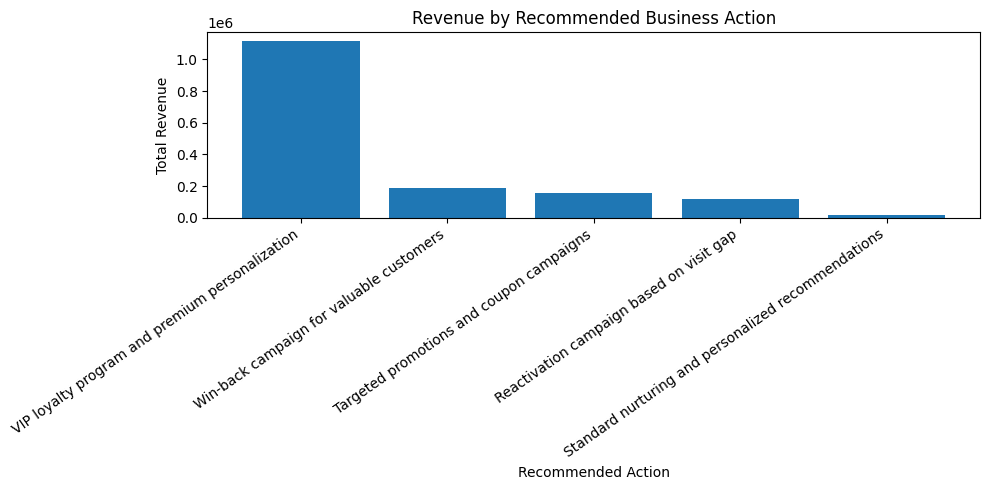

In [22]:
plt.figure(figsize=(10, 5))
plt.bar(action_summary['recommended_action'], action_summary['total_revenue'])
plt.title('Revenue by Recommended Business Action')
plt.xlabel('Recommended Action')
plt.ylabel('Total Revenue')
plt.xticks(rotation=35, ha='right')
save_current_figure('fig_13_action_revenue.png')
plt.show()

## 9. Segment playbook generation

Builds a readable playbook that can be included in the final report or used by Module 5.

In [23]:
playbook_rows = []

for _, row in hybrid_overview.sort_values('total_revenue', ascending=False).iterrows():
    playbook_rows.append({
        'segment': row['hybrid_segment'],
        'customers': int(row['customers']),
        'revenue': round(row['total_revenue'], 2),
        'avg_monetary': round(row['avg_monetary'], 2),
        'avg_frequency': round(row['avg_frequency'], 2),
        'avg_recency': round(row['avg_recency'], 2),
        'recommended_action': row['recommended_action']
    })

playbook = pd.DataFrame(playbook_rows)
display(playbook)

,segment,customers,revenue,avg_monetary,avg_frequency,avg_recency,recommended_action
0,High-Value | High-Value Frequent Discount-Sensitive,1834,783385.19,427.15,15.31,68.50,VIP loyalty program and premium personalization
1,Mid-Value | High-Value Inactive Large-Basket,828,130844.26,158.02,4.13,383.05,Win-back campaign for valuable customers
2,High-Value | High-Value Inactive Large-Basket,345,126572.71,366.88,8.20,136.79,VIP loyalty program and premium personalization
3,Mid-Value | Low-Value Inactive Standard,784,84132.41,107.31,4.83,307.75,Reactivation campaign based on visit gap
4,High-Value | Low-Value Frequent Weekend-Oriented,446,80521.21,180.54,11.79,49.29,VIP loyalty program and premium personalization
5,High-Value | Mid-Value Occasional Discount-Sensitive,362,77694.33,214.63,9.75,78.02,VIP loyalty program and premium personalization
6,Mid-Value | Mid-Value Occasional Discount-Sensitive,596,60857.09,102.11,4.74,270.70,Targeted promotions and coupon campaigns
7,Low-Value | High-Value Inactive Large-Basket,872,56559.09,64.86,1.59,737.44,Win-back campaign for valuable customers
8,Low-Value | Low-Value Inactive Standard,1551,53473.44,34.48,1.74,696.04,Targeted promotions and coupon campaigns
9,High-Value | Low-Value Inactive Standard,243,47054.72,193.64,8.87,122.35,VIP loyalty program and premium personalization


## 10. Export final BI artifacts

Saves final customer-level and segment-level outputs for dashboards, report writing, and Module 5.

In [24]:
# Add recommended action to each customer via hybrid segment
recommended_action_map = dict(zip(
    hybrid_overview["hybrid_segment"],
    hybrid_overview["recommended_action"]
))

customer_segments["recommended_action"] = customer_segments["hybrid_segment"].map(recommended_action_map)

# Save final customer-level segmentation output
customer_segments.to_csv(FINAL_SEGMENTS_PATH, index=False)

# Save targeting lists
vip_customers.to_csv(os.path.join(OUTPUT_DIR, "target_vip_customers.csv"), index=False)
churn_risk_customers.to_csv(os.path.join(OUTPUT_DIR, "target_churn_risk_customers.csv"), index=False)
winback_customers.to_csv(os.path.join(OUTPUT_DIR, "target_winback_customers.csv"), index=False)
discount_sensitive_customers.to_csv(os.path.join(OUTPUT_DIR, "target_discount_sensitive_customers.csv"), index=False)
large_basket_customers.to_csv(os.path.join(OUTPUT_DIR, "target_large_basket_customers.csv"), index=False)
weekend_customers.to_csv(os.path.join(OUTPUT_DIR, "target_weekend_customers.csv"), index=False)

# Save Excel workbook with segment profiles
try:
    with pd.ExcelWriter(SEGMENT_PROFILES_XLSX_PATH, engine="openpyxl") as writer:
        summary_kpis.to_excel(writer, sheet_name="Executive KPIs", index=False)
        rfm_overview.to_excel(writer, sheet_name="RFM Segments", index=False)
        kmeans_overview.to_excel(writer, sheet_name="KMeans Segments", index=False)
        hybrid_overview.to_excel(writer, sheet_name="Hybrid Segments", index=False)
        targeting_summary.to_excel(writer, sheet_name="Targeting Summary", index=False)
        action_summary.to_excel(writer, sheet_name="Action Summary", index=False)
        playbook.to_excel(writer, sheet_name="Playbook", index=False)

    print("Saved Excel workbook:", SEGMENT_PROFILES_XLSX_PATH)

except Exception as e:
    print("Excel export failed:", e)
    print("CSV outputs were still saved successfully.")

# Save markdown playbook
lines = []
lines.append("# Module 4 Targeting Playbook")
lines.append("")
lines.append("This playbook summarizes the final hybrid customer segments and recommended actions.")
lines.append("")

for _, row in playbook.iterrows():
    lines.append(f"## {row['segment']}")
    lines.append(f"- Customers: {row['customers']}")
    lines.append(f"- Revenue: {row['revenue']}")
    lines.append(f"- Average monetary value: {row['avg_monetary']}")
    lines.append(f"- Average frequency: {row['avg_frequency']}")
    lines.append(f"- Average recency: {row['avg_recency']}")
    lines.append(f"- Recommended action: {row['recommended_action']}")
    lines.append("")

with open(TARGETING_PLAYBOOK_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

# Save compact JSON summary
business_summary = {
    "total_customers": int(total_customers),
    "total_revenue": float(round(total_revenue, 2)),
    "rfm_segments": int(customer_segments["rfm_segment"].nunique()),
    "kmeans_segments": int(customer_segments["kmeans_cluster"].nunique()),
    "hybrid_segments": int(customer_segments["hybrid_segment"].nunique()),
    "top_rfm_segment_by_revenue": str(rfm_overview.iloc[0]["rfm_segment"]),
    "top_kmeans_segment_by_revenue": str(kmeans_overview.iloc[0]["kmeans_segment_name"]),
    "top_hybrid_segment_by_revenue": str(hybrid_overview.iloc[0]["hybrid_segment"]),
    "top_recommended_action_by_revenue": str(action_summary.iloc[0]["recommended_action"]),
    "outputs": {
        "customer_segments_final": FINAL_SEGMENTS_PATH,
        "segment_profiles_xlsx": SEGMENT_PROFILES_XLSX_PATH,
        "targeting_playbook": TARGETING_PLAYBOOK_PATH,
        "figures_dir": FIGURE_DIR
    }
}

with open(INSIGHTS_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(business_summary, f, indent=2)

print("Saved final customer segments:", FINAL_SEGMENTS_PATH)
print("Saved targeting playbook:", TARGETING_PLAYBOOK_PATH)
print("Saved insights summary:", INSIGHTS_SUMMARY_PATH)
print("Saved figures in:", FIGURE_DIR)

Excel export failed: No module named 'openpyxl'
CSV outputs were still saved successfully.
Saved final customer segments: ../Module 4\customer_segments_final.csv
Saved targeting playbook: ../Module 4\targeting_playbook.md
Saved insights summary: ../Module 4\business_insights_summary.json
Saved figures in: ../Module 4/figures_notebook3


## 11. Final notebook summary

Final check of all outputs generated by Notebook 3.

In [25]:
print("Final customer segmentation output:", FINAL_SEGMENTS_PATH)
print("Shape:", customer_segments.shape)
print("Unique customers:", customer_segments["customer_id"].nunique())
print("RFM segments:", customer_segments["rfm_segment"].nunique())
print("K-Means segments:", customer_segments["kmeans_segment_name"].nunique())
print("Hybrid segments:", customer_segments["hybrid_segment"].nunique())

print("")
print("Top 5 hybrid segments by revenue:")

display(
    hybrid_overview[
        ["hybrid_segment", "customers", "total_revenue", "revenue_pct", "recommended_action"]
    ].head(5)
)

print("")
print("Generated figure files:")

for fig_name in sorted(os.listdir(FIGURE_DIR)):
    if fig_name.endswith(".png"):
        print(fig_name)

Final customer segmentation output: ../Module 4\customer_segments_final.csv
Shape: (10001, 85)
Unique customers: 10001
RFM segments: 9
K-Means segments: 5
Hybrid segments: 15

Top 5 hybrid segments by revenue:


,hybrid_segment,customers,total_revenue,revenue_pct,recommended_action
0,High-Value | High-Value Frequent Discount-Sensitive,1834,783385.19,48.904057,VIP loyalty program and premium personalization
11,Mid-Value | High-Value Inactive Large-Basket,828,130844.26,8.168160,Win-back campaign for valuable customers
1,High-Value | High-Value Inactive Large-Basket,345,126572.71,7.901501,VIP loyalty program and premium personalization
13,Mid-Value | Low-Value Inactive Standard,784,84132.41,5.252099,Reactivation campaign based on visit gap
2,High-Value | Low-Value Frequent Weekend-Oriented,446,80521.21,5.026664,VIP loyalty program and premium personalization



Generated figure files:
fig_01_rfm_customer_count.png
fig_02_rfm_revenue_contribution.png
fig_03_rfm_revenue_share_pie.png
fig_04_kmeans_customer_count.png
fig_05_kmeans_revenue.png
fig_06_kmeans_profile_heatmap.png
fig_07_hybrid_customer_count.png
fig_08_hybrid_revenue.png
fig_09_hybrid_revenue_pareto.png
fig_10_hybrid_bubble_value_size.png
fig_11_targeting_group_sizes.png
fig_12_targeting_group_revenue.png
fig_13_action_revenue.png
